Shape: (7043, 20)

Churn Distribution:
Churn
0    5174
1    1869
Name: count, dtype: int64


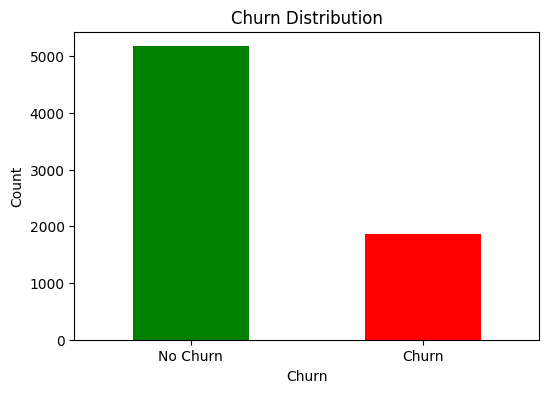

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load Dataset
df = pd.read_csv('../data/Churn Prediction Dataset.csv')

# Clean Data
df = df.drop('customerID', axis=1)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())
df['Churn'] = (df['Churn'] == 'Yes').astype(int)

print("Shape:", df.shape)
print("\nChurn Distribution:")
print(df['Churn'].value_counts())

# Plot Churn Distribution
plt.figure(figsize=(6,4))
df['Churn'].value_counts().plot(kind='bar', color=['green','red'])
plt.title('Churn Distribution')
plt.xticks([0,1], ['No Churn','Churn'], rotation=0)
plt.ylabel('Count')
plt.show()

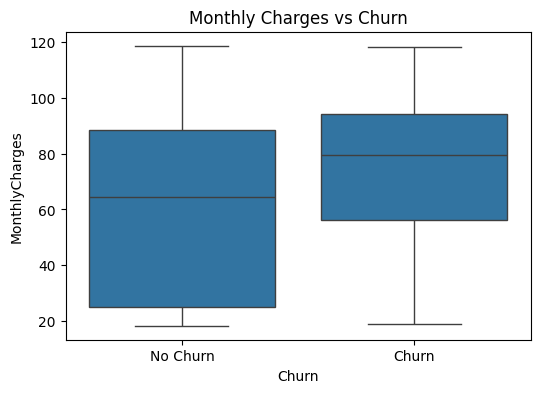

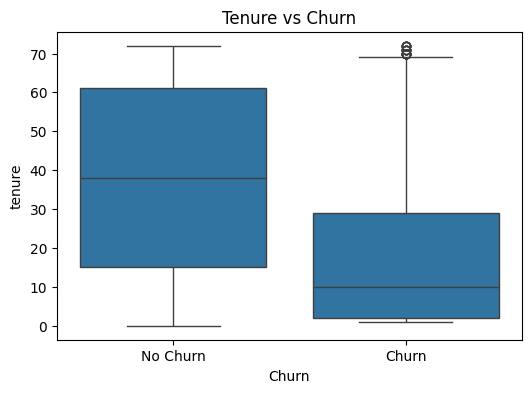

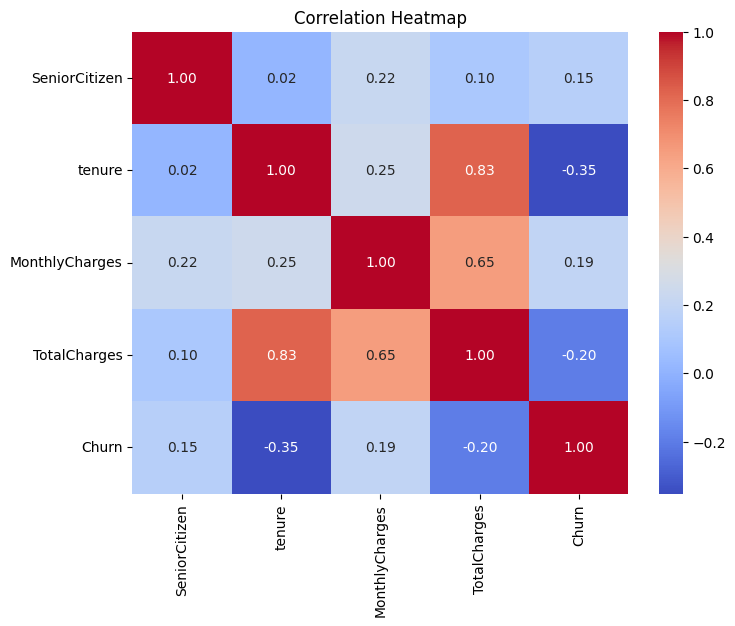

In [2]:
# Monthly Charges vs Churn
plt.figure(figsize=(6,4))
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)
plt.title('Monthly Charges vs Churn')
plt.xticks([0,1], ['No Churn','Churn'])
plt.show()

# Tenure vs Churn
plt.figure(figsize=(6,4))
sns.boxplot(x='Churn', y='tenure', data=df)
plt.title('Tenure vs Churn')
plt.xticks([0,1], ['No Churn','Churn'])
plt.show()

# Correlation Heatmap
plt.figure(figsize=(8,6))
sns.heatmap(df.select_dtypes(include='number').corr(), 
            annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Encode categorical variables
le = LabelEncoder()
cat_cols = df.select_dtypes(include=['object', 'str']).columns.tolist()

for col in cat_cols:
    df[col] = le.fit_transform(df[col])

# Features and target
X = df.drop(['Churn'], axis=1)
y = df['Churn']

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)
print("Train size:", X_train.shape, "| Test size:", X_test.shape)

Train size: (5634, 19) | Test size: (1409, 19)


=== Logistic Regression ===
Accuracy: 0.815471965933286
              precision    recall  f1-score   support

           0       0.86      0.90      0.88      1036
           1       0.68      0.58      0.62       373

    accuracy                           0.82      1409
   macro avg       0.77      0.74      0.75      1409
weighted avg       0.81      0.82      0.81      1409



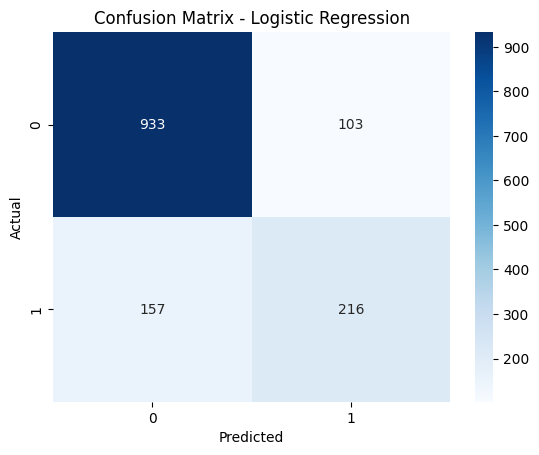

In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

print("=== Logistic Regression ===")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

cm = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.show()